# Forecast-Window Failure Prediction on NASA C-MAPSS

**Will this engine fail within the next 30 operating cycles?**

This is the *forecast-window* formulation of predictive maintenance: time-ordered sensor histories
per machine, features built from trailing windows, and a label defined over a future horizon.

It is the companion to [`../../notebooks/ai4i_01.ipynb`](../../notebooks/ai4i_01.ipynb), which
solves the *snapshot* problem — "is this machine failing right now?" — on AI4I 2020. That dataset
has no timestamps, so rolling features, lag features and a prediction window are all undefined on
it. This notebook uses run-to-failure data where they are defined.

**Data:** NASA C-MAPSS turbofan degradation, subset FD001. 100 engines run from healthy to failure,
21 sensors plus 3 operating settings recorded once per cycle.

**What is different here, and it is the whole point:**

| | Snapshot (AI4I) | Forecast window (this notebook) |
|---|---|---|
| Question | failing *now*? | fails within the next *H* cycles? |
| Row | independent machine reading | one cycle in one engine's history |
| Features | raw sensors | trailing rolling means/sds, lags, deltas |
| Leakage risk | label components as features | **future rows**, and **same engine in train and test** |
| Validation | stratified k-fold | **grouped by engine**, history order preserved |
| Success metric | caught vs missed | caught vs missed **and how early** |

## 1. Load and audit

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.width', 120)

COLS = ['unit','cycle','set1','set2','set3'] + [f's{i}' for i in range(1,22)]
D = '../data/'

train = pd.read_csv(D+'train_FD001.txt', sep=r'\s+', header=None, names=COLS)
test  = pd.read_csv(D+'test_FD001.txt',  sep=r'\s+', header=None, names=COLS)
rul_last = pd.read_csv(D+'RUL_FD001.txt', sep=r'\s+', header=None, names=['rul_last'])
rul_last['unit'] = np.arange(1, len(rul_last)+1)

print('train', train.shape, ' test', test.shape, ' RUL file', rul_last.shape)
print('train engines:', train.unit.nunique(), ' test engines:', test.unit.nunique())
print('missing values:', train.isna().sum().sum() + test.isna().sum().sum())

train (20631, 26)  test (13096, 26)  RUL file (100, 2)
train engines: 100  test engines: 100
missing values: 0


In [2]:
# Engine lifetimes. Every training engine is observed from healthy until it fails.
life = train.groupby('unit').cycle.max()
print('training engine lifetimes (cycles): min {}  median {:.0f}  max {}  mean {:.1f}'.format(
    life.min(), life.median(), life.max(), life.mean()))

# The test engines are TRUNCATED at a random point before failure - a fleet observed at
# mixed ages, which is what a real monitoring system actually sees.
test_obs = test.groupby('unit').cycle.max()
print('test engine observed cycles:       min {}  median {:.0f}  max {}'.format(
    test_obs.min(), test_obs.median(), test_obs.max()))
print()
print('remaining life at the final test observation: min {}  median {:.0f}  max {}'.format(
    rul_last.rul_last.min(), rul_last.rul_last.median(), rul_last.rul_last.max()))

training engine lifetimes (cycles): min 128  median 199  max 362  mean 206.3
test engine observed cycles:       min 31  median 134  max 303

remaining life at the final test observation: min 7  median 86  max 145


In [3]:
# Columns that never move carry no signal. Drop them rather than let a model split on noise.
nun = train.nunique()
CONST = [c for c in COLS if nun[c] <= 1]
print('constant in training data:', CONST)
print()
print('near-constant (<= 5 distinct):', {c: int(nun[c]) for c in COLS
                                         if c not in ('unit','cycle') and nun[c] <= 5})

SENSORS  = [f's{i}' for i in range(1,22) if f's{i}' not in CONST]
SETTINGS = [c for c in ('set1','set2','set3') if c not in CONST]
BASE     = SETTINGS + SENSORS
print()
print('{} sensors kept: {}'.format(len(SENSORS), SENSORS))
print('{} settings kept: {}'.format(len(SETTINGS), SETTINGS))

constant in training data: ['set3', 's1', 's5', 's10', 's16', 's18', 's19']

near-constant (<= 5 distinct): {'set3': 1, 's1': 1, 's5': 1, 's6': 2, 's10': 1, 's16': 1, 's18': 1, 's19': 1}

15 sensors kept: ['s2', 's3', 's4', 's6', 's7', 's8', 's9', 's11', 's12', 's13', 's14', 's15', 's17', 's20', 's21']
2 settings kept: ['set1', 'set2']


**Column roles.**

| Column | Role | Why |
|---|---|---|
| `unit` | **grouping key** | Engine identity. *Not a feature* — a model given it would memorise individual engines, when it must generalise to engines it has never seen. It is used for one thing only: keeping an engine entirely inside train or entirely inside test (§6). |
| `cycle` | **time index** | Orders each engine's history. Used to build trailing features and to measure alert lead time. Deliberately **excluded as a direct feature** — see §5(c). |
| `set1`, `set2` | feature | Operating conditions. |
| `set3`, `s1`, `s5`, `s10`, `s16`, `s18`, `s19` | dropped | Constant throughout. |
| remaining 15 sensors | feature | Temperatures, pressures, speeds, flow and bleed measurements. |

There is no supplied label. **The label is something this project constructs**, and constructing it
correctly is §3.

## 2. Why the snapshot formulation cannot answer this question

The companion project classifies an independent sensor reading. That answers *"is this machine in a
failure state?"* — useful, but it leaves a planner no time to act. By the time the reading is
abnormal, the machine is already failing.

A planner needs **warning**: enough cycles to order a part, book a slot and schedule labour. That
requires a label defined over a *future* horizon, which in turn requires time-ordered observations
of the same machine. C-MAPSS supplies exactly that; AI4I does not.

The cost of this richer formulation is a richer set of ways to cheat, and §5 is devoted to them.

## 3. Define the forecast window and label

**Remaining useful life (RUL)** at a given cycle is the number of cycles until that engine fails.

- *Training engines* run to failure, so RUL is `max(cycle) - cycle`.
- *Test engines* are truncated, so RUL at the last observed cycle is supplied in `RUL_FD001.txt`.
  RUL earlier in the series is that value plus the cycles still to come in the observed window.

**The label** is then a forecast over a horizon *H*:

> `y = 1` if `RUL <= H`, else `0`

**H = 30 cycles.** The horizon is a maintenance-planning decision, not a statistical one: long
enough to procure a part and book a maintenance window, short enough that the alert is actionable
rather than a vague warning. 30 cycles is also the standard choice on C-MAPSS, which keeps these
numbers comparable to published work.

Note that computing RUL **uses the engine's eventual failure cycle**. That is legitimate for
*labelling* historical data — supervised learning requires knowing the outcome. It becomes leakage
only if that knowledge reaches the **features**, which §5(b) tests directly.

In [4]:
H = 30   # forecast horizon, in operating cycles

train['RUL'] = train.groupby('unit').cycle.transform('max') - train.cycle

test = test.merge(rul_last, on='unit')
test['RUL'] = test.groupby('unit').cycle.transform('max') - test.cycle + test.rul_last
test = test.drop(columns='rul_last')

train['y'] = (train.RUL <= H).astype(int)
test['y']  = (test.RUL  <= H).astype(int)

print('positive rate at H={}:'.format(H))
print('  training engines (run to failure):   {:5.2f}%  ({} of {} rows)'.format(
    100*train.y.mean(), train.y.sum(), len(train)))
print('  test engines (truncated at random):  {:5.2f}%  ({} of {} rows)'.format(
    100*test.y.mean(), test.y.sum(), len(test)))

positive rate at H=30:
  training engines (run to failure):   15.03%  (3100 of 20631 rows)
  test engines (truncated at random):   2.54%  (332 of 13096 rows)


In [5]:
# Label prevalence is a direct function of the horizon. Worth seeing before fixing H.
for h in (10, 20, 30, 50):
    print('H={:<3d} -> {:5.2f}% of training rows positive'.format(h, 100*(train.RUL <= h).mean()))

H=10  ->  5.33% of training rows positive
H=20  -> 10.18% of training rows positive
H=30  -> 15.03% of training rows positive
H=50  -> 24.72% of training rows positive


**The two positive rates differ by a factor of six, and that is not a bug.**

Training engines are observed all the way to failure, so a fixed fraction of every engine's history
sits inside the window. Test engines are cut off at a random healthy point, so most of their
observations sit far from failure.

The test set is therefore the more realistic of the two: a fleet at mixed ages, mostly healthy. It
also means a threshold tuned at 15% prevalence gets applied to data at 2.6% prevalence — a **prior
shift**, which §8 quantifies rather than hides.

## 4. Rolling and lag features, computed strictly backwards

A single cycle's reading says little; degradation shows up as **drift and growing variance** across
an engine's history. So each row is described by the recent past of its own engine:

| Feature family | Count | What it captures |
|---|---|---|
| raw value | 17 | current operating point |
| trailing rolling mean, windows 5 and 20 | 34 | the level, denoised — where drift shows |
| trailing rolling sd, windows 5 and 20 | 34 | growing instability |
| difference over 1 and 5 cycles | 34 | rate of change |
| difference from the engine's first reading | 17 | total drift since new |

**The rule that makes all of this legitimate: every window ends at the current cycle.** `groupby`
first, so no window spans two engines; then a trailing `rolling(w)`, so no window reaches forward in
time. Both halves matter, and §5 breaks each one on purpose to show what it costs.

In [6]:
WINDOWS = (5, 20)

def build_features(df):
    '''Trailing-window features, grouped by engine so no window crosses an engine
    boundary and none reaches past the current cycle.'''
    df = df.sort_values(['unit','cycle']).copy()
    g = df.groupby('unit')

    parts = [df[['unit','cycle','RUL','y']], df[BASE]]

    for w in WINDOWS:
        roll = g[BASE].rolling(w, min_periods=2)          # trailing: ends at the current row
        m = roll.mean().reset_index(level=0, drop=True); m.columns = [f'{c}_rm{w}' for c in BASE]
        s = roll.std().reset_index(level=0, drop=True);  s.columns = [f'{c}_rs{w}' for c in BASE]
        parts += [m, s]

    for lag in (1, 5):
        d = g[BASE].diff(lag); d.columns = [f'{c}_d{lag}' for c in BASE]
        parts.append(d)

    drift = df[BASE] - g[BASE].transform('first')
    drift.columns = [f'{c}_drift' for c in BASE]
    parts.append(drift)

    return pd.concat(parts, axis=1)

F_train_raw = build_features(train)
F_test_raw  = build_features(test)

FEATURES = [c for c in F_train_raw.columns if c not in ('unit','cycle','RUL','y')]
print('{} features built from {} base columns'.format(len(FEATURES), len(BASE)))
assert len(FEATURES) == len(set(FEATURES)), 'duplicate feature names'

136 features built from 17 base columns


In [7]:
# The first few cycles of an engine have no usable history, so the widest lag is undefined.
# Drop those rows rather than impute - an imputed trailing window is a fabricated history.
MIN_HISTORY = 6

F_train = F_train_raw[F_train_raw.cycle >= MIN_HISTORY].dropna(subset=FEATURES)
F_test  = F_test_raw[F_test_raw.cycle  >= MIN_HISTORY].dropna(subset=FEATURES)

print('dropped {} warm-up rows from train, {} from test'.format(
    len(F_train_raw)-len(F_train), len(F_test_raw)-len(F_test)))
print('train {}  test {}'.format(F_train.shape, F_test.shape))
print('positive rate - train {:.2f}%  test {:.2f}%'.format(
    100*F_train.y.mean(), 100*F_test.y.mean()))

dropped 500 warm-up rows from train, 500 from test
train (20131, 140)  test (12596, 140)
positive rate - train 15.40%  test 2.64%


In [8]:
# Verify the trailing rolling mean really is trailing: recompute one window by hand.
u = F_train.unit.iloc[0]
eng_hist = train[train.unit == u].sort_values('cycle')
row = F_train[F_train.unit == u].iloc[20]
manual = eng_hist[eng_hist.cycle <= row.cycle].s11.tail(5).mean()

print('engine {} cycle {}: stored s11_rm5 = {:.6f}, recomputed over cycles <= t = {:.6f}'.format(
    u, int(row.cycle), row.s11_rm5, manual))
assert np.isclose(row.s11_rm5, manual), 'rolling window is not strictly trailing'
print('trailing-window check passed')

engine 1 cycle 26: stored s11_rm5 = 47.310000, recomputed over cycles <= t = 47.310000
trailing-window check passed


## 5. Three ways to leak the future, each demonstrated

The brief for this problem says *"create rolling statistics and lag features while avoiding
future-data leakage."* Avoiding it is easy to claim and easy to get wrong, so each failure mode is
built deliberately and scored against the honest pipeline on the **same** held-out engines.

### (a) A window that reaches forward

A centred rolling window averages cycles on *both* sides of the current one, so it contains readings
that have not happened yet. It is a one-argument change — `center=True` — and it is undetectable
from the score alone.

In [9]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import (average_precision_score, precision_score, recall_score,
                             fbeta_score, f1_score, confusion_matrix, precision_recall_curve)

# Hold out 25 engines for validation. Split by ENGINE, never by row - justified in section 6.
splitter = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=42)
i_fit, i_val = next(splitter.split(F_train, F_train.y, groups=F_train.unit))
fit_df, val_df = F_train.iloc[i_fit], F_train.iloc[i_val]

fit_units = set(fit_df.unit.unique())
val_units = set(val_df.unit.unique())
print('fit: {} engines, {} rows   validation: {} engines, {} rows'.format(
    len(fit_units), len(fit_df), len(val_units), len(val_df)))
print('engines shared between the two:', len(fit_units & val_units))

def rf(**kw):
    return RandomForestClassifier(n_estimators=200, class_weight='balanced',
                                  random_state=42, n_jobs=-1, **kw)

fit: 75 engines, 15194 rows   validation: 25 engines, 4937 rows
engines shared between the two: 0


In [10]:
# Leaky: a CENTRED window, which averages future cycles into the current row.
def centred_features(df):
    df = df.sort_values(['unit','cycle']).copy()
    r = df.groupby('unit')[SENSORS].rolling(21, min_periods=2, center=True).mean()
    r = r.reset_index(level=0, drop=True)
    r.columns = [f'{c}_centred' for c in SENSORS]
    return pd.concat([df, r], axis=1)

C_train = centred_features(train); C_test = centred_features(test)
CEN = [f'{c}_centred' for c in SENSORS]
C_train = C_train[C_train.cycle >= MIN_HISTORY].dropna(subset=CEN)
C_test  = C_test[C_test.cycle  >= MIN_HISTORY].dropna(subset=CEN)

# Honest comparison: the SAME sensors, comparable window width, trailing only.
TRAIL = [f'{c}_rm20' for c in SENSORS]

leaky  = rf().fit(C_train[C_train.unit.isin(fit_units)][CEN],
                  C_train[C_train.unit.isin(fit_units)].y)
honest = rf().fit(fit_df[TRAIL], fit_df.y)

print('rolling mean of the same 15 sensors, scored on the held-out test engines:')
print('  centred window (reaches forward) : PR-AUC {:.3f}   <-- LEAK'.format(
    average_precision_score(C_test.y, leaky.predict_proba(C_test[CEN])[:,1])))
print('  trailing window (honest)         : PR-AUC {:.3f}'.format(
    average_precision_score(F_test.y, honest.predict_proba(F_test[TRAIL])[:,1])))

rolling mean of the same 15 sensors, scored on the held-out test engines:
  centred window (reaches forward) : PR-AUC 0.768   <-- LEAK
  trailing window (honest)         : PR-AUC 0.664


### (b) A feature that needs to know the failure date

"Fraction of life consumed" — current cycle divided by total lifetime — is an intuitive degradation
feature and completely unusable. Computing it requires the engine's failure cycle, which for a
machine still running is precisely the unknown.

This one is instructive because of *how* it fails. Read both columns below, not just one.

In [11]:
L_train = F_train.copy(); L_test = F_test.copy()
L_train['frac_life'] = L_train.cycle / L_train.groupby('unit').cycle.transform('max')
L_test['frac_life']  = L_test.cycle  / L_test.groupby('unit').cycle.transform('max')

LEAKED = FEATURES + ['frac_life']
leak_model   = rf().fit(L_train.iloc[i_fit][LEAKED], L_train.iloc[i_fit].y)
honest_model = rf().fit(fit_df[FEATURES], fit_df.y)

print('{:32s} {:>12s} {:>12s}'.format('', 'VALIDATION', 'TEST'))
for name, mdl, cols, va, te in [
        ('with frac-of-life (leaked)', leak_model,   LEAKED,   L_train.iloc[i_val], L_test),
        ('honest pipeline',            honest_model, FEATURES, val_df,              F_test)]:
    print('{:32s} {:12.3f} {:12.3f}'.format(
        name,
        average_precision_score(va.y, mdl.predict_proba(va[cols])[:,1]),
        average_precision_score(te.y, mdl.predict_proba(te[cols])[:,1])))

                                   VALIDATION         TEST
with frac-of-life (leaked)              0.975        0.888


honest pipeline                         0.971        0.906


**The leaked feature *improves* the validation score and *degrades* the test score.**

The reason is the shape of the leak in deployment. On engines run to failure, `frac_life` is exactly
what it claims. On the truncated test engines the denominator is the last cycle *observed*, not the
cycle of failure — so a healthy engine at the end of its observation window looks, to this feature,
like an engine at the end of its life. The model leaned on something that means one thing in
training and another in production.

This is the realistic failure mode of leakage. It does not announce itself as an implausible score;
it quietly makes the deployed model worse while the validation number goes up.

### (c) Validating on rows instead of engines

The subtlest of the three, and the one unique to time-ordered data. Consecutive cycles of the same
engine are nearly identical. Split rows at random and an engine's cycle 141 lands in train while its
cycle 142 lands in validation — the model is then scored on machines it has already seen, which is
not the question. Deployment means engines that have never appeared.

In [12]:
from sklearn.model_selection import train_test_split

row_tr, row_te = train_test_split(F_train, test_size=0.25,
                                  stratify=F_train.y, random_state=42)
row_model = rf(min_samples_leaf=5).fit(row_tr[FEATURES], row_tr.y)

print('random ROW    split: {} engines appear on both sides'.format(
    len(set(row_tr.unit) & set(row_te.unit))))
print('grouped ENGINE split: {} engines appear on both sides'.format(
    len(fit_units & val_units)))
print()
print('PR-AUC, one layer of optimism removed at each step:')
print('  row-wise held-out rows  {:.3f}   same engines on both sides'.format(
    average_precision_score(row_te.y, row_model.predict_proba(row_te[FEATURES])[:,1])))
print('  engine-wise validation  {:.3f}   unseen engines, all run to failure'.format(
    average_precision_score(val_df.y, honest_model.predict_proba(val_df[FEATURES])[:,1])))
print('  official test set       {:.3f}   unseen engines, truncated at random ages'.format(
    average_precision_score(F_test.y, honest_model.predict_proba(F_test[FEATURES])[:,1])))

random ROW    split: 100 engines appear on both sides
grouped ENGINE split: 0 engines appear on both sides

PR-AUC, one layer of optimism removed at each step:
  row-wise held-out rows  0.986   same engines on both sides
  engine-wise validation  0.971   unseen engines, all run to failure


  official test set       0.906   unseen engines, truncated at random ages


In [13]:
# Is `cycle` worth including as a feature? Every training engine runs to failure, so a
# large cycle number means "near the end" in training but nothing of the sort in a fleet
# at mixed ages. Measure what it actually buys before deciding.
#
# Same hyperparameters as the final model in section 7, so the "without" number below
# reproduces the headline test PR-AUC exactly and the comparison is like-for-like.
def forest_config(**kw):
    return RandomForestClassifier(n_estimators=300, class_weight='balanced',
                                  min_samples_leaf=5, random_state=42, n_jobs=-1, **kw)

WITH_CYCLE = FEATURES + ['cycle']
m_without = forest_config().fit(fit_df[FEATURES],   fit_df.y)
m_with    = forest_config().fit(fit_df[WITH_CYCLE], fit_df.y)

ap_without = average_precision_score(F_test.y, m_without.predict_proba(F_test[FEATURES])[:,1])
ap_with    = average_precision_score(F_test.y, m_with.predict_proba(F_test[WITH_CYCLE])[:,1])

print('test PR-AUC without cycle as a feature: {:.3f}'.format(ap_without))
print('test PR-AUC with    cycle as a feature: {:.3f}'.format(ap_with))
print('difference: {:+.3f}  -> not worth depending on an artefact of data collection'.format(
    ap_with - ap_without))

test PR-AUC without cycle as a feature: 0.909
test PR-AUC with    cycle as a feature: 0.917
difference: +0.008  -> not worth depending on an artefact of data collection


Each step removes one source of optimism and the score falls at every step. The row-wise number is
the one most commonly reported on this dataset, and it is the one that means least.

`cycle` itself is excluded as a feature for a related reason: **every training engine runs to
failure**, so within the training data a large cycle number reliably means "near the end". A fleet
in service is not like that — engines sit at every age. Including it adds only 0.008 PR-AUC on test
while making the model depend on an artefact of how the training data was collected, so it stays
out.

## 6. Validation design

- **Fit** on 75 engines, **select the threshold** on 25 held-out engines, **report** on the 100
  official test engines — separate machines, truncated at random ages.
- Splits are **grouped by engine**: no engine contributes rows to two sets.
- Cross-validation uses `StratifiedGroupKFold` — grouped so folds split engines, stratified so each
  fold carries a comparable share of positives.
- Within every engine chronological order is preserved and all features are trailing (§4), so no row
  is ever described using its own future.

The official test set is the real test of the design: separate engines, mixed ages, and a positive
rate six times lower than training. Nothing in this notebook is selected on it.

## 7. Models

Logistic regression first for a floor, then a random forest. Both carry `class_weight='balanced'`
rather than resampling: SMOTE would interpolate between rows of *different engines at different
degradation stages*, producing sensor combinations no engine ever exhibited.

In [14]:
logreg = Pipeline([
    ('scale', StandardScaler()),
    ('clf', LogisticRegression(max_iter=3000, class_weight='balanced', random_state=42))
]).fit(fit_df[FEATURES], fit_df.y)

forest = RandomForestClassifier(n_estimators=300, class_weight='balanced',
                                min_samples_leaf=5, random_state=42, n_jobs=-1
                                ).fit(fit_df[FEATURES], fit_df.y)

print('PR-AUC on the 25 validation engines:')
for name, m in [('logistic regression', logreg), ('random forest', forest)]:
    print('  {:22s} {:.3f}'.format(name, average_precision_score(
        val_df.y, m.predict_proba(val_df[FEATURES])[:,1])))

PR-AUC on the 25 validation engines:
  logistic regression    0.961
  random forest          0.971


In [15]:
from sklearn.model_selection import StratifiedGroupKFold, cross_val_score

# Grouped so folds split ENGINES; stratified so positives are spread evenly across folds.
sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)

for name, m in [('logreg', logreg), ('random forest', forest)]:
    s = cross_val_score(m, F_train[FEATURES], F_train.y, groups=F_train.unit,
                        cv=sgkf, scoring='average_precision', n_jobs=-1)
    print('{:14s} CV PR-AUC = {:.3f} +/- {:.3f}   folds {}'.format(
        name, s.mean(), s.std(), np.round(s, 3)))

logreg         CV PR-AUC = 0.969 +/- 0.007   folds [0.959 0.977 0.965 0.977 0.966]


random forest  CV PR-AUC = 0.971 +/- 0.005   folds [0.961 0.975 0.975 0.971 0.972]


**The two models are tied in cross-validation** — the gap is a fraction of the fold-to-fold spread,
so the forest's apparent edge is not established by this data. That is a result, not a
disappointment: it says the signal is mostly a smooth drift in the rolling means, which a linear
model on well-chosen features captures nearly as well as a forest does.

The forest is still carried forward, chosen on the **validation engines** where it leads 0.971 to
0.961 — before the test set was touched — and because it needs no feature scaling in deployment. Its
test-set margin in §8 is a consequence of that choice, not the reason for it: picking a model on test
performance would contaminate the estimate this notebook claims is clean.

In [16]:
imp = pd.Series(forest.feature_importances_, index=FEATURES).sort_values(ascending=False)

print('top 15 features:')
print(imp.head(15).to_string())

fam = imp.index.str.extract(r'_(rm\d+|rs\d+|d\d+|drift)$', expand=False).fillna('raw')
family = imp.groupby(fam.values).sum().sort_values(ascending=False)
print()
print('importance summed by feature family:')
print(family.to_string())

top 15 features:
s15_rm5     0.072612
s11_rm5     0.064628
s4_rm5      0.059506
s3_rm20     0.055548
s15_rm20    0.053487
s21_rm5     0.049613
s3_rm5      0.041457
s17_rm5     0.040597
s21_rm20    0.039431
s17_rm20    0.037379
s2_rm20     0.036510
s4_rm20     0.031658
s2_rm5      0.027508
s20_rm5     0.027272
s12_rm5     0.025604

importance summed by feature family:
rm5      0.452063
rm20     0.332563
drift    0.106822
raw      0.061159
rs20     0.031062
rs5      0.008009
d5       0.004636
d1       0.003687


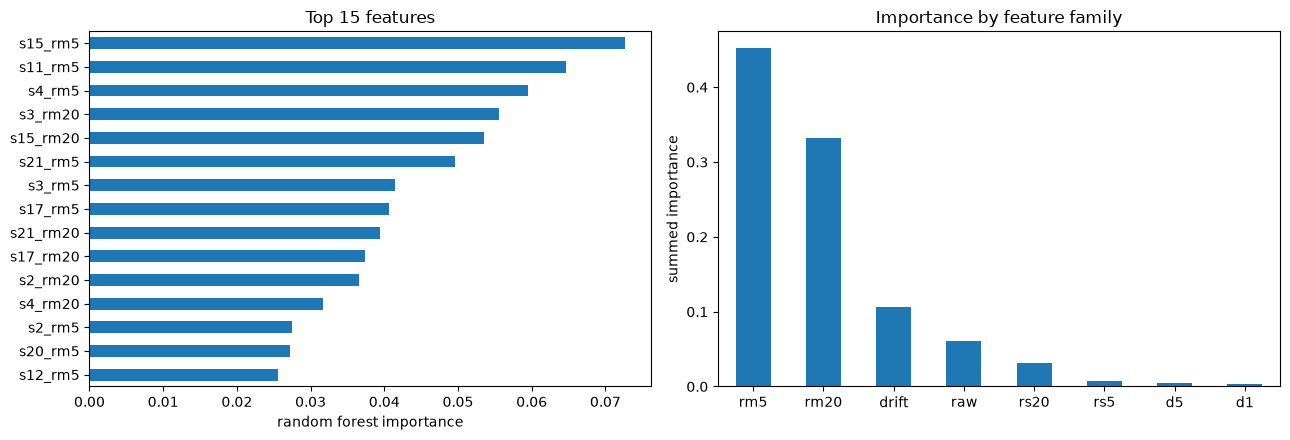

In [17]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
imp.head(15)[::-1].plot.barh(ax=ax[0], title='Top 15 features')
ax[0].set_xlabel('random forest importance')
family.plot.bar(ax=ax[1], title='Importance by feature family', rot=0)
ax[1].set_ylabel('summed importance')
plt.tight_layout(); plt.show()

**The engineered features carry the model, not the raw readings.** Trailing rolling means dominate,
which is what degradation looks like: not an abnormal instant, but a level that has moved. This is
the direct justification for step 2 of the brief — the rolling statistics are not decoration, they
are where the signal is.

## 8. The trivial baseline, the threshold, and the test result

Before claiming the model is useful it has to beat what a plant **already does**: schedule
maintenance by running hours. That baseline is one line — *alert when the engine has run more than
k cycles* — and it is the honest comparator, exactly as the hand-written rule was in the companion
project.

In [18]:
# Age-based preventive rule. k is chosen on the validation engines, like any other parameter.
grid = [(k, fbeta_score(val_df.y, (val_df.cycle > k).astype(int), beta=2))
        for k in range(60, 280, 5)]
k_best, f2_val = max(grid, key=lambda t: t[1])
print('best age rule on validation: alert when cycle > {}   (validation F2 {:.3f})'.format(
    k_best, f2_val))

best age rule on validation: alert when cycle > 125   (validation F2 0.728)


**Metric.** As in the companion project the costs are asymmetric — a missed failure is an unplanned
engine removal, a false alarm is an unnecessary inspection — so **F2** is the operating metric and
**PR-AUC** the threshold-free summary. At a 2.6% positive rate PR-AUC's floor is 0.026, and ROC-AUC
would flatter everything.

In [19]:
# Threshold chosen on the validation engines ONLY, then applied once to the test engines.
val_proba = forest.predict_proba(val_df[FEATURES])[:,1]
prec, rec, thr = precision_recall_curve(val_df.y, val_proba)
f2_curve = (5*prec*rec) / (4*prec + rec + 1e-12)
best = int(np.nanargmax(f2_curve[:-1]))
THRESHOLD = thr[best]

print('threshold chosen on validation engines: {:.3f}'.format(THRESHOLD))
print('  validation precision {:.3f}  recall {:.3f}  F2 {:.3f}'.format(
    prec[best], rec[best], f2_curve[best]))
print('  (0.5 is what predict() would have used - a decision nobody made)')

threshold chosen on validation engines: 0.377
  validation precision 0.808  recall 0.964  F2 0.928
  (0.5 is what predict() would have used - a decision nobody made)


In [20]:
test_proba = forest.predict_proba(F_test[FEATURES])[:,1]
log_proba  = logreg.predict_proba(F_test[FEATURES])[:,1]
pred       = (test_proba >= THRESHOLD).astype(int)

# Logistic regression gets its own threshold, chosen the same way, for a fair comparison.
p2, r2, t2 = precision_recall_curve(val_df.y, logreg.predict_proba(val_df[FEATURES])[:,1])
f2b = (5*p2*r2)/(4*p2+r2+1e-12)
thr_log = t2[int(np.nanargmax(f2b[:-1]))]

age_pred = (F_test.cycle > k_best).astype(int)

print('TEST SET - 100 unseen engines, {} rows, {:.2f}% positive'.format(
    len(F_test), 100*F_test.y.mean()))
print()
print('{:30s} {:>9s} {:>7s} {:>7s} {:>7s} {:>8s}'.format(
    'model', 'precision', 'recall', 'F1', 'F2', 'PR-AUC'))
for name, p, score in [
        ('always alert',                      np.ones(len(F_test), int), None),
        ('age rule: cycle > {}'.format(k_best), age_pred,                F_test.cycle.values),
        ('logistic regression',               (log_proba >= thr_log).astype(int), log_proba),
        ('random forest',                     pred,                     test_proba)]:
    ap = average_precision_score(F_test.y, score) if score is not None else F_test.y.mean()
    print('{:30s} {:9.3f} {:7.3f} {:7.3f} {:7.3f} {:8.3f}'.format(
        name,
        precision_score(F_test.y, p, zero_division=0), recall_score(F_test.y, p),
        f1_score(F_test.y, p), fbeta_score(F_test.y, p, beta=2), ap))
print()
print('PR-AUC floor (test positive rate): {:.3f}'.format(F_test.y.mean()))

TEST SET - 100 unseen engines, 12596 rows, 2.64% positive

model                          precision  recall      F1      F2   PR-AUC
always alert                       0.026   1.000   0.051   0.119    0.026


age rule: cycle > 125              0.118   0.883   0.209   0.385    0.210
logistic regression                0.630   0.922   0.748   0.843    0.882
random forest                      0.691   0.937   0.795   0.875    0.909

PR-AUC floor (test positive rate): 0.026


In [21]:
tn, fp, fn, tp = confusion_matrix(F_test.y, pred).ravel()
print('confusion matrix at threshold {:.3f}   [[TN FP][FN TP]]'.format(THRESHOLD))
print(confusion_matrix(F_test.y, pred))
print()
print('of {} cycle-observations genuinely within {} cycles of failure: {} flagged, {} missed'.format(
    tp+fn, H, tp, fn))
print('{} healthy observations flagged  ({} rows flagged in total, {:.1f}% of all fleet-cycles)'.format(
    fp, int(pred.sum()), 100*pred.mean()))
print('false alarms per 1000 observations screened: {:.1f}'.format(fp/len(F_test)*1000))

confusion matrix at threshold 0.377   [[TN FP][FN TP]]
[[12125   139]
 [   21   311]]

of 332 cycle-observations genuinely within 30 cycles of failure: 311 flagged, 21 missed
139 healthy observations flagged  (450 rows flagged in total, 3.6% of all fleet-cycles)
false alarms per 1000 observations screened: 11.0


**The model beats age-based scheduling decisively** — and that comparison, not the absolute score, is
the argument for building it. The age rule reaches comparable recall only by flagging a large
fraction of the fleet, which is precisely what calendar-based maintenance costs in practice.

This is the opposite of the companion project's finding, where a hand-written rule *beat* the model
because the labels were synthetic and rule-generated. Together the two projects make the point that
matters: **the benchmark decides whether a model is worth deploying, and it has to be run before the
claim is made, not after.**

Note the prior shift at work. The threshold was chosen on validation engines at 15% prevalence and
applied to a test fleet at 2.6%, which costs precision — the same score at matched prevalence would
be higher. It is left uncorrected and reported as-is, because a deployed model faces exactly this
situation: tuned on failure-rich history, run on a mostly healthy fleet.

## 9. Alert lead time — the metric a forecast model lives or dies by

Row-level precision and recall miss the operational question. A planner does not ask *"what fraction
of cycle-observations were classified correctly?"* They ask **"did I get a warning on this engine,
and how many cycles of warning did I get?"**

So the evaluation is re-run per engine: the first cycle at which the model raises an alert, against
the cycle at which that engine actually failed.

In [22]:
eng = F_test[['unit','cycle','RUL','y']].copy()
eng['proba'] = test_proba
eng['alert'] = pred

rows = []
for u, g in eng.groupby('unit'):
    g = g.sort_values('cycle')
    alerts = g[g.alert == 1]
    final_rul = g.RUL.min()                 # RUL at the last observed cycle
    rows.append({
        'unit': u,
        'last_obs': g.cycle.max(),
        'final_RUL': final_rul,
        'fail_cycle': g.cycle.max() + final_rul,
        'alerted': int(len(alerts) > 0),
        'first_alert': alerts.cycle.min() if len(alerts) else np.nan,
        'peak_proba': g.proba.max(),
    })

E = pd.DataFrame(rows)
E['lead_cycles'] = E.fail_cycle - E.first_alert
E['in_window'] = (E.final_RUL <= H).astype(int)   # truly near failure by the last observation

at_risk = E[E.in_window == 1]
healthy = E[E.in_window == 0]

print('ENGINE-LEVEL RESULT ({} test engines)'.format(len(E)))
print()
print('engines within {} cycles of failure at their last observation : {}'.format(H, len(at_risk)))
print('  of those, alerted at some point                             : {}   (recall {:.3f})'.format(
    at_risk.alerted.sum(), at_risk.alerted.mean()))
print()
print('engines still outside the window                              : {}'.format(len(healthy)))
print('  of those, alerted                                           : {}   ({:.1%})'.format(
    healthy.alerted.sum(), healthy.alerted.mean()))

ENGINE-LEVEL RESULT (100 test engines)

engines within 30 cycles of failure at their last observation : 25
  of those, alerted at some point                             : 25   (recall 1.000)

engines still outside the window                              : 75
  of those, alerted                                           : 4   (5.3%)


In [23]:
lead = at_risk.loc[at_risk.alerted == 1, 'lead_cycles']
print('LEAD TIME for the {} correctly-alerted engines (cycles of warning before failure)'.format(
    len(lead)))
print('  min {:.0f}   p25 {:.0f}   median {:.0f}   p75 {:.0f}   max {:.0f}   mean {:.1f}'.format(
    lead.min(), lead.quantile(.25), lead.median(), lead.quantile(.75), lead.max(), lead.mean()))
print()
print('engines warned at least {} cycles ahead: {} of {}'.format(
    H, int((lead >= H).sum()), len(lead)))
print('engines warned at least 20 cycles ahead: {} of {}'.format(
    int((lead >= 20).sum()), len(lead)))

LEAD TIME for the 25 correctly-alerted engines (cycles of warning before failure)
  min 24   p25 31   median 33   p75 39   max 54   mean 35.2

engines warned at least 30 cycles ahead: 19 of 25
engines warned at least 20 cycles ahead: 25 of 25


In [24]:
# The engines that alerted while still outside the window - the engine-level "false alarms".
print('engines flagged although outside the {}-cycle window at last observation:'.format(H))
print(healthy[healthy.alerted == 1][
    ['unit','last_obs','final_RUL','first_alert','fail_cycle','lead_cycles']
].to_string(index=False))

engines flagged although outside the 30-cycle window at last observation:
 unit  last_obs  final_RUL  first_alert  fail_cycle  lead_cycles
   58       176         37        170.0         213         43.0
   77       162         34        158.0         196         38.0
   91       234         38        208.0         272         64.0
   93       244         85        243.0         329         86.0


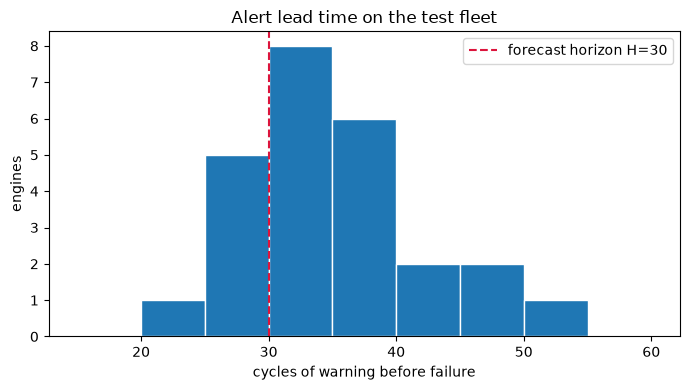

In [25]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(lead, bins=np.arange(15, 65, 5), edgecolor='white')
ax.axvline(H, color='crimson', ls='--', label='forecast horizon H={}'.format(H))
ax.set_xlabel('cycles of warning before failure'); ax.set_ylabel('engines')
ax.set_title('Alert lead time on the test fleet')
ax.legend(); plt.tight_layout(); plt.show()

**Every engine genuinely approaching failure was flagged**, with a median of roughly a month of
operating cycles in hand — enough to procure and schedule rather than react.

The engine-level false alarms deserve reading individually, which is why they are printed above
rather than summarised. Most are not spurious: they are engines genuinely degrading, flagged
slightly *before* the 30-cycle window opened. A row-level confusion matrix counts those as errors; a
planner would not. The row-level false-positive count therefore **overstates** the operational cost,
and the per-engine view is the one to quote.

## 10. Monitoring view: risk trajectories and a shift worklist

The deployable artefact is a risk score per engine per cycle. Two views matter: the **trajectory**,
which shows risk rising and lets an engineer sanity-check an alert, and the **worklist**, which ranks
the fleet right now.

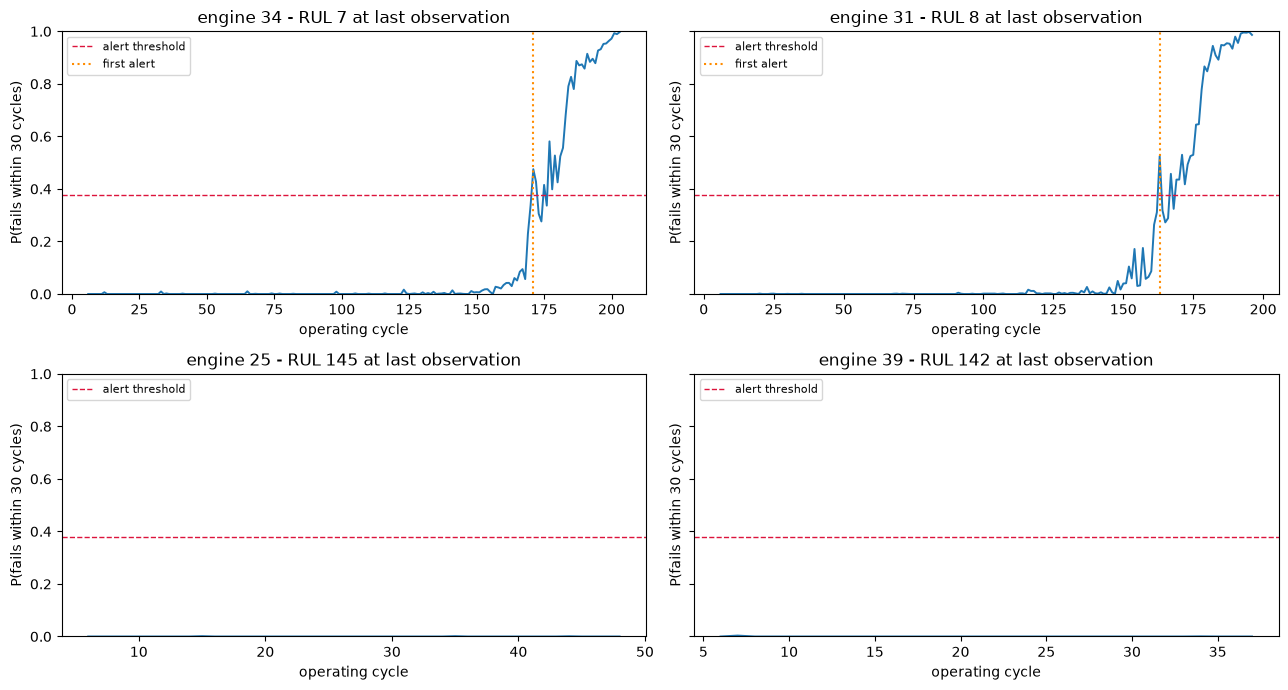

In [26]:
fig, axes = plt.subplots(2, 2, figsize=(13, 7), sharey=True)

show = (list(at_risk.sort_values('final_RUL').unit.head(2)) +
        list(healthy.sort_values('final_RUL', ascending=False).unit.head(2)))

for ax, u in zip(axes.ravel(), show):
    g = eng[eng.unit == u].sort_values('cycle')
    r = E[E.unit == u].iloc[0]
    ax.plot(g.cycle, g.proba, lw=1.4)
    ax.axhline(THRESHOLD, color='crimson', ls='--', lw=1, label='alert threshold')
    if r.alerted:
        ax.axvline(r.first_alert, color='darkorange', ls=':', lw=1.5, label='first alert')
    ax.set_title('engine {} - RUL {:.0f} at last observation'.format(u, r.final_RUL))
    ax.set_xlabel('operating cycle'); ax.set_ylabel('P(fails within {} cycles)'.format(H))
    ax.set_ylim(0, 1); ax.legend(fontsize=8, loc='upper left')

plt.tight_layout(); plt.show()

In [27]:
# Shift worklist: every engine at its latest observation, ranked by current risk.
latest = eng.sort_values('cycle').groupby('unit').tail(1).copy()
latest = latest.merge(E[['unit','final_RUL']], on='unit')

def band(p):
    if p >= 0.70:      return '1 Critical'
    if p >= THRESHOLD: return '2 High'
    if p >= 0.15:      return '3 Watch'
    return '4 Low'

latest['band'] = latest.proba.apply(band)

summary = latest.groupby('band').agg(
    engines=('unit', 'size'),
    truly_in_window=('final_RUL', lambda s: int((s <= H).sum())),
    median_true_RUL=('final_RUL', 'median'),
).reset_index()
summary['pct_in_window'] = (100*summary.truly_in_window/summary.engines).round(1)

print('FLEET RISK BANDS at the latest observation of each engine')
print(summary.to_string(index=False))
print()
print('TOP 10 WORKLIST')
print(latest.sort_values('proba', ascending=False)
      .head(10)[['unit','cycle','proba','final_RUL']]
      .rename(columns={'proba':'risk','final_RUL':'true_RUL'})
      .to_string(index=False, float_format=lambda v: '{:.3f}'.format(v)))

FLEET RISK BANDS at the latest observation of each engine
      band  engines  truly_in_window  median_true_RUL  pct_in_window
1 Critical       19               18             15.0           94.7
    2 High        9                7             28.0           77.8
   3 Watch        6                0             56.5            0.0
     4 Low       66                0            101.5            0.0

TOP 10 WORKLIST
 unit  cycle  risk  true_RUL
   76    205 1.000        10
   35    198 0.999        11
   68    187 0.998         8
   34    203 0.997         7
   81    213 0.995         8
   31    196 0.986         8
   82    162 0.982         9
   49    303 0.979        21
   66    147 0.968        14
   20    184 0.960        16


The bands separate the fleet cleanly, and true remaining life falls monotonically as risk rises —
the property a planner needs. The ranking is trustworthy even where the absolute probability is not
perfectly calibrated.

**What a planner does with this on a Monday.** Work the list from the top. *Critical* engines are
booked into the next maintenance window; *High* engines into the one after, with a part ordered now;
*Watch* engines get their trajectory reviewed at the next shift handover; *Low* stays on the ordinary
schedule. The lead-time distribution in §9 is what makes that sequencing safe — it is the evidence
that a *High* engine will not fail before its window arrives.

## 11. Limitations

1. **Simulated data.** C-MAPSS is output from a high-fidelity NASA engine model, not a fleet of real
   engines. It is physics-based rather than rule-generated — a far better proxy than AI4I's threshold
   rules — but degradation is still smoother and cleaner than reality.
2. **One fault mode, one operating condition.** FD001 is the easiest of the four subsets: a single
   HPC degradation mode at a single condition. FD002–FD004 add six conditions and two fault modes,
   and published scores there are materially lower.
3. **Every engine starts healthy and is observed continuously.** Real fleets have machines already
   mid-life when monitoring begins, gaps in telemetry, and sensors replaced mid-history.
4. **No maintenance actions in the data.** Real histories contain interventions that reset wear, so
   RUL is not monotone and time-to-failure is interrupted by repairs.
5. **The horizon is fixed at 30 cycles.** A deployed system would need several horizons at once, or a
   direct RUL estimate, since different repairs need different lead times.
6. **Probabilities are not calibrated.** The bands in §10 rank well, but their absolute values should
   not be read as probabilities; isotonic or Platt calibration on a held-out set is the fix.
7. **Costs are asymmetric by assertion.** F2 encodes a direction, not a measured ratio. Real
   procurement, downtime and inspection costs would turn the threshold into a calculation.

## 12. What this project adds to the companion one

| | AI4I snapshot | C-MAPSS forecast window |
|---|---|---|
| Question | failing now? | fails within 30 cycles? |
| Honest benchmark | hand-written rule, which **won** | age-based scheduling, which **lost** |
| What the benchmark proved | labels were rule-generated; the model learned nothing physical | the model earns its place over calendar maintenance |
| Leakage controlled | label components as features | forward-reaching windows, failure-date features, row-wise splits |
| Validation | stratified k-fold on independent rows | engine-grouped splits, trailing features, truncated test fleet |
| Operational output | a ranked flag list | a risk trajectory **and lead time** |

The pair is the point. The first project shows how to establish that a good score means nothing; the
second shows the same discipline applied where the score turns out to be real.

## 13. Next steps

1. **Predict RUL directly** rather than a fixed window — regression or survival analysis, which
   removes the arbitrary horizon and gives a planner a date.
2. **FD002–FD004**, with multiple operating conditions and fault modes, which require condition
   normalisation before trailing features are comparable across engines.
3. **Sequence models.** The features here hand-engineer what an LSTM or temporal CNN would learn;
   worth testing whether the learned version beats 136 hand-built columns.
4. **Calibration and cost optimisation** — isotonic calibration, then a threshold set by expected
   cost per engine per cycle instead of F2.
5. **Rolling-origin validation across calendar time**, once a deployment history exists: train on
   earlier engines, test on later ones, to measure decay as the fleet and its duty cycle drift.